# Final Project: Stroke Risk Assessment Using Fuzzy Logic
**Course:** Introduction to Artificial Intelligence | **Date:** June 15, 2026

---

### **Team Members**
* **Axella N. H.**
* **Anita W. M.**
* **Amalina M.**

### **Project Overview**
This notebook implements a Fuzzy Inference System entirely from scratch to predict stroke risk. It processes clinical patient data and directly compares the inference, performance, and output differences between **Mamdani** and **Sugeno** methodologies. No external fuzzy logic libraries were used in this implementation.

### **Dataset Information**
* **Source:** Kaggle Healthcare Dataset (Stroke Data)
* **Link:** [Healthcare Dataset - Stroke Data](https://www.kaggle.com/datasets/aouatifcherdid/healthcare-dataset-stroke-data)
* **Size:** 5,110 rows
* **Inputs:** Age, Average Glucose Level, BMI, Hypertension, Smoking Status
* **Output:** Stroke Risk

## **Environment Setup**
Setting up a clean workspace by removing any existing versions of the repository, performing a fresh clone from GitHub to access the latest dataset, and configuring the working directory.

In [ ]:
import os
import shutil

repo_name = 'Intro-to-AI-Final-Project'
repo_url = 'https://github.com/ax-ch/Intro-to-AI-Final-Project.git'

if os.path.exists(repo_name):
    print(f"Directory '{repo_name}' already exists. Deleting for a fresh clone...")
    shutil.rmtree(repo_name)

!git clone {repo_url}
print("Repository cloned successfully.")

%cd {repo_name}

Directory 'Intro-to-AI-Final-Project' already exists. Deleting for a fresh clone...
Cloning into 'Intro-to-AI-Final-Project'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 55 (delta 15), reused 43 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 859.39 KiB | 5.93 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Repository cloned successfully.
/content/Intro-to-AI-Final-Project


## **Core Dependencies**
Importing the fundamental Python libraries required for dataset manipulation (`pandas`) and numerical operations (`numpy`).

In [ ]:
import pandas as pd
import numpy as np

## **Data Cleaning & Preprocessing**
Loading the dataset and preparing it for the mathematical fuzzy engine. This step drops irrelevant identifiers, handles missing BMI values via mean imputation, and numerically encodes categorical text features (e.g., smoking status) for processing.

In [ ]:
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')

# Drop 'id' column (no predictive value)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Handle missing BMI values. Coerce errors to NaN (handles 'N/A' strings), then fill with mean.
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Map text categorical variables to numeric values
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})
df['work_type'] = df['work_type'].map({
    'children': 0, 'Never_worked': 1, 'Govt_job': 2, 'Private': 3, 'Self-employed': 4
})
df['residence_type'] = df['residence_type'].map({'Rural': 0, 'Urban': 1})
df['smoking_status'] = df['smoking_status'].map({
    'Unknown': 0, 'never smoked': 1, 'formerly smoked': 2, 'smokes': 3
})

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData ready for Fuzzy Engine. Total rows and column:", df.shape)

Missing values after cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Data ready for Fuzzy Engine. Total rows and column: (5110, 11)


Displaying a sample of the cleaned dataset to visually verify the categorical mappings and missing value imputations. The preprocessed data is then saved locally as a reliable checkpoint before we initialize the custom fuzzy mathematics.

In [ ]:
display(df.head(10))

# Save on repo (note: not immediately on GitHub)
df.to_csv('data/cleaned_fuzzified_stroke_data.csv', index=False)

print("Data successfully saved to the /data folder!")

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,3,1,228.69,36.600000,2,1
1,1,61.0,0,0,1,4,0,202.21,28.893237,1,1
2,0,80.0,0,1,1,3,0,105.92,32.500000,1,1
3,1,49.0,0,0,1,3,1,171.23,34.400000,3,1
4,1,79.0,1,0,1,4,0,174.12,24.000000,1,1
5,0,81.0,0,0,1,3,1,186.21,29.000000,2,1
6,0,74.0,1,1,1,3,0,70.09,27.400000,1,1
7,1,69.0,0,0,0,3,1,94.39,22.800000,1,1
8,1,59.0,0,0,1,3,0,76.15,28.893237,0,1
9,1,78.0,0,0,1,3,1,58.57,24.200000,0,1


Data successfully saved to the /data folder!


## **Core Mathematical Functions**
Defining the foundational fuzzy logic membership shapes: Triangular (`trimf`) and Trapezoidal (`trapmf`). Crucially, these formulas are built entirely from scratch to satisfy the strict assignment constraint prohibiting external fuzzy libraries. They are vectorized via `numpy` to process the 5,000+ row dataset efficiently.

In [ ]:
def trimf(x, params):
    """Triangular membership function."""
    a, b, c = params
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a) if a != b else 1.0
    elif b < x < c:
        return (c - x) / (c - b) if b != c else 1.0
    return 0.0

def trapmf(x, params):
    """Trapezoidal membership function."""
    a, b, c, d = params
    if x <= a or x >= d:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a) if a != b else 1.0
    elif b <= x <= c:
        return 1.0
    elif c < x < d:
        return (d - x) / (d - c) if c != d else 1.0
    return 0.0

vectorized_trimf = np.vectorize(trimf, excluded=['params'])
vectorized_trapmf = np.vectorize(trapmf, excluded=['params'])

## **Fuzzification (Linguistic Variables)**
Applying the custom membership functions to map crisp dataset values into fuzzy membership degrees ($\mu$). This process translates the **5 input variables**, i.e. Age, Glucose, BMI, Smoking Status, and Hypertension, into their respective linguistic categories (e.g., Young, Middle, Senior) based on predefined medical parameters.

In [ ]:
# Format: trimf -> [a, b, c] | trapmf -> [a, b, c, d]

# AGE
age_young_params = [0, 0, 30, 45]             # Trapezoid
age_middle_params = [30, 50, 70]              # Triangle
age_senior_params = [55, 70, 100, 100]        # Trapezoid

# GLUCOSE
gluc_normal_params = [0, 0, 90, 140]          # Trapezoid
gluc_prediab_params = [100, 150, 200]         # Triangle
gluc_diabetic_params = [150, 200, 350, 350]   # Trapezoid

# BMI
bmi_low_norm_params = [0, 0, 18.5, 25]        # Trapezoid
bmi_overwt_params = [20, 27.5, 35]            # Triangle
bmi_obese_params = [30, 35, 100, 100]         # Trapezoid

# SMOKING (0=Unknown, 1=Never, 2=Former, 3=Smokes)
smoke_low_params = [-1, 0, 1, 1.5]
smoke_mod_params = [1, 2, 3]
smoke_high_params = [2.5, 3, 4, 4]

# HYPERTENSION
ht_absent_params = [-1, 0, 0.5]
ht_present_params = [0.5, 1, 2]

# Membership Degrees
# AGE
df['mu_age_young'] = vectorized_trapmf(df['age'], params=age_young_params)
df['mu_age_middle'] = vectorized_trimf(df['age'], params=age_middle_params)
df['mu_age_senior'] = vectorized_trapmf(df['age'], params=age_senior_params)

# GLUCOSE
df['mu_gluc_normal'] = vectorized_trapmf(df['avg_glucose_level'], params=gluc_normal_params)
df['mu_gluc_prediab'] = vectorized_trimf(df['avg_glucose_level'], params=gluc_prediab_params)
df['mu_gluc_diab'] = vectorized_trapmf(df['avg_glucose_level'], params=gluc_diabetic_params)

# BMI
df['mu_bmi_low'] = vectorized_trapmf(df['bmi'], params=bmi_low_norm_params)
df['mu_bmi_over'] = vectorized_trimf(df['bmi'], params=bmi_overwt_params)
df['mu_bmi_obese'] = vectorized_trapmf(df['bmi'], params=bmi_obese_params)

# SMOKING
df['mu_smoke_low'] = vectorized_trapmf(df['smoking_status'], params=smoke_low_params)
df['mu_smoke_mod'] = vectorized_trimf(df['smoking_status'], params=smoke_mod_params)
df['mu_smoke_high'] = vectorized_trapmf(df['smoking_status'], params=smoke_high_params)

# HYPERTENSION
df['mu_ht_absent'] = vectorized_trimf(df['hypertension'], params=ht_absent_params)
df['mu_ht_present'] = vectorized_trimf(df['hypertension'], params=ht_present_params)

print("Fuzzification complete. Membership degrees calculated for all rows.")

Fuzzification complete. Membership degrees calculated for all rows.


## **Inference (Rule Evaluation)**
Executing the 15 predefined fuzzy logic rules. This step uses the `np.minimum` function to represent the fuzzy **AND** operator (calculating the firing strength of each rule) and `np.maximum.reduce` for the fuzzy **OR** operator to aggregate these strengths into three final risk weights: **Low**, **Medium**, and **High**.

In [ ]:
# HIGH RISK RULES
w1 = np.minimum(df['mu_age_senior'], df['mu_ht_present'])
w2 = np.minimum(df['mu_gluc_diab'], df['mu_bmi_obese'])
w3 = np.minimum(df['mu_age_senior'], np.minimum(df['mu_smoke_high'], df['mu_ht_present']))
w4 = np.minimum(df['mu_gluc_diab'], df['mu_ht_present'])
w5 = np.minimum(df['mu_age_middle'], np.minimum(df['mu_smoke_high'], df['mu_ht_present']))

df['weight_high'] = np.maximum.reduce([w1, w2, w3, w4, w5])

# MEDIUM RISK RULES
w6 = np.minimum(df['mu_age_middle'], np.minimum(df['mu_ht_absent'], df['mu_smoke_mod']))
w7 = np.minimum(df['mu_age_senior'], np.minimum(df['mu_gluc_normal'], df['mu_ht_absent']))
w8 = np.minimum(df['mu_bmi_over'], df['mu_smoke_mod'])
w9 = np.minimum(df['mu_age_middle'], df['mu_gluc_prediab'])
w10 = np.minimum(df['mu_age_young'], df['mu_ht_present'])

df['weight_med'] = np.maximum.reduce([w6, w7, w8, w9, w10])

# LOW RISK RULES
w11 = np.minimum(df['mu_age_young'], df['mu_ht_absent'])
w12 = np.minimum(df['mu_gluc_normal'], df['mu_bmi_low'])
w13 = np.minimum(df['mu_age_young'], df['mu_smoke_low'])
w14 = np.minimum(df['mu_age_middle'], np.minimum(df['mu_gluc_normal'], df['mu_ht_absent']))
w15 = np.minimum(df['mu_smoke_low'], np.minimum(df['mu_ht_absent'], df['mu_bmi_low']))

df['weight_low'] = np.maximum.reduce([w11, w12, w13, w14, w15])

print("Inference complete. Weights calculated for Low, Medium, and High risk.")

Inference complete. Weights calculated for Low, Medium, and High risk.


## **Sugeno Defuzzification (Zero-Order Method)**
Translating the aggregated fuzzy weights into a final, crisp risk score using the Sugeno method. This approach calculates a weighted average based on predefined constant outputs (`z_low = 0.1`, `z_med = 0.5`, `z_high = 0.9`). Safe division is implemented to handle any edge cases where no rules fire.

In [ ]:
# Constant output values
z_low = 0.1
z_med = 0.5
z_high = 0.9

# Weighted Average
numerator = (df['weight_low'] * z_low) + (df['weight_med'] * z_med) + (df['weight_high'] * z_high)
denominator = df['weight_low'] + df['weight_med'] + df['weight_high']

# Protect against division by zero (if no rules fire)
df['Sugeno_Risk_Score'] = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

print("Sugeno Defuzzification complete.")

Sugeno Defuzzification complete.


## **Mamdani Defuzzification (Centroid Method)**
Calculating the final risk score using the Mamdani Center of Gravity (Centroid) approach. This custom function discretizes the continuous output domain (0.0 to 1.0) into 50 points. It then clips the output membership functions based on the inferred rule weights, aggregates the areas via the `MAX` operator, and computes the mathematical center. This explicit implementation strictly satisfies the requirement to avoid external fuzzy libraries.

In [ ]:
# Output Parameters (Risk scale from 0 to 1)
risk_low_params = [0, 0, 0.3, 0.5]            # Trapezoid
risk_med_params = [0.3, 0.5, 0.7]             # Triangle
risk_high_params = [0.5, 0.7, 1.0, 1.0]       # Trapezoid

# Discrete array of output values (z)
z_values = np.linspace(0, 1, 50)

# Base membership degrees for array Z
mu_z_low = vectorized_trapmf(z_values, params=risk_low_params)
mu_z_med = vectorized_trimf(z_values, params=risk_med_params)
mu_z_high = vectorized_trapmf(z_values, params=risk_high_params)

# Defuzzification Function for a single row
def calculate_centroid(row):
    clipped_low = np.minimum(row['weight_low'], mu_z_low)
    clipped_med = np.minimum(row['weight_med'], mu_z_med)
    clipped_high = np.minimum(row['weight_high'], mu_z_high)

    aggregated = np.maximum.reduce([clipped_low, clipped_med, clipped_high])

    area = np.sum(aggregated)
    if area == 0:
        return 0.0

    return np.sum(aggregated * z_values) / area

df['Mamdani_Risk_Score'] = df.apply(calculate_centroid, axis=1)

print("Mamdani Defuzzification complete.")

Mamdani Defuzzification complete.


Displaying a side-by-side comparison of the newly calculated `Mamdani_Risk_Score` and `Sugeno_Risk_Score` alongside the ground truth `stroke` label. After verifying the continuous outputs, the fully processed dataset is saved locally to preserve the calculated risk scores for model evaluation.

In [ ]:
display(df[['age', 'hypertension', 'Mamdani_Risk_Score', 'Sugeno_Risk_Score', 'stroke']].head(10))

df.to_csv('data/compared_risk_scores_stroke_data.csv', index=False)

print("Data successfully saved to the /data folder!")

,age,hypertension,Mamdani_Risk_Score,Sugeno_Risk_Score,stroke
0,67.0,0,0.763742,0.847826,1
1,61.0,0,0.000000,0.000000,1
2,80.0,0,0.500000,0.500000,1
3,49.0,0,0.649271,0.669840,1
4,79.0,1,0.790522,0.900000,1
5,81.0,0,0.500000,0.500000,1
6,74.0,1,0.790522,0.900000,1
7,69.0,0,0.383590,0.391750,1
8,59.0,0,0.291618,0.230612,1
9,78.0,0,0.446972,0.456164,1


Data successfully saved to the /data folder!


## **Performance Evaluation (Mamdani vs. Sugeno)**
Converting the continuous fuzzy risk scores (0.0 to 1.0) into discrete binary predictions using a 0.5 threshold to match the dataset's ground truth labels. This section calculates classification metrics to directly evaluate and compare the predictive accuracy of the Mamdani and Sugeno architectures, fulfilling the core analytical requirement of the project.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Set threshold to convert continuous risk (0-1) to binary stroke prediction (0 or 1)
threshold = 0.5

df['Mamdani_Predict'] = (df['Mamdani_Risk_Score'] >= threshold).astype(int)
df['Sugeno_Predict'] = (df['Sugeno_Risk_Score'] >= threshold).astype(int)

# Calculate metrics against ground truth 'stroke' column
mamdani_acc = accuracy_score(df['stroke'], df['Mamdani_Predict'])
sugeno_acc = accuracy_score(df['stroke'], df['Sugeno_Predict'])

print(f"Mamdani Accuracy: {mamdani_acc:.4f}")
print(f"Sugeno Accuracy: {sugeno_acc:.4f}")

Mamdani Accuracy: 0.8419
Sugeno Accuracy: 0.7912


### **Output Distribution Analysis (Mamdani vs. Sugeno)**
Visualizing the continuous risk score distributions to highlight the operational differences between the two architectures. Because Sugeno utilizes a zero-order weighted average of constants, its outputs tend to cluster differently than Mamdani, which calculates a geometric centroid over a continuous output space.

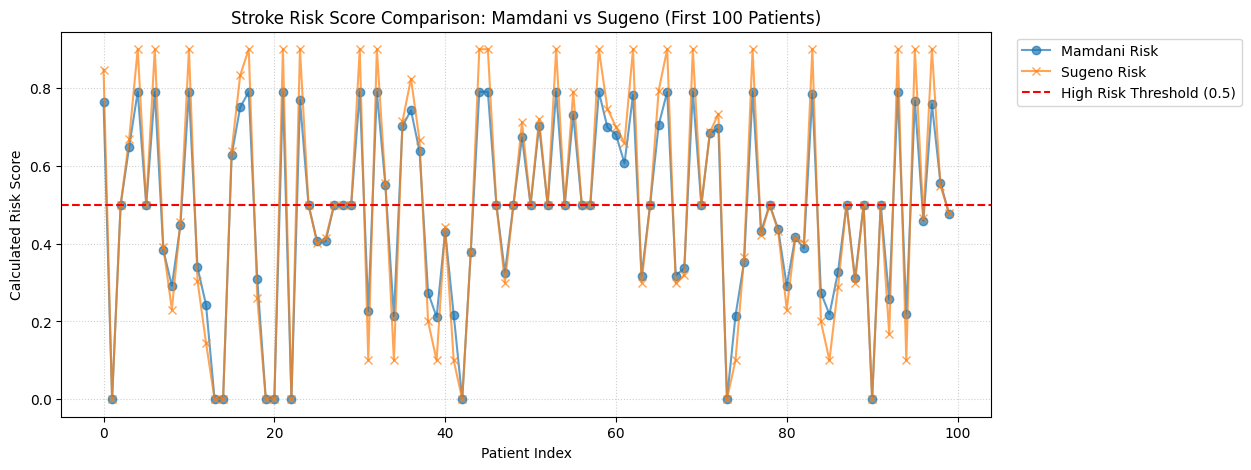

Visualization successfully saved to the /images folder!


In [ ]:
import matplotlib.pyplot as plt

# Sample 100 patients
sample_df = df.head(100)

plt.figure(figsize=(12, 5))
plt.plot(sample_df.index, sample_df['Mamdani_Risk_Score'], label='Mamdani Risk', marker='o', alpha=0.7)
plt.plot(sample_df.index, sample_df['Sugeno_Risk_Score'], label='Sugeno Risk', marker='x', alpha=0.7)

plt.axhline(y=0.5, color='r', linestyle='--', label='High Risk Threshold (0.5)')
plt.title('Stroke Risk Score Comparison: Mamdani vs Sugeno (First 100 Patients)')
plt.xlabel('Patient Index')
plt.ylabel('Calculated Risk Score')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True, linestyle=':', alpha=0.6)

os.makedirs('images', exist_ok=True)
plt.savefig('images/stroke_risk_comparison.png', dpi=300, bbox_inches='tight')

plt.show()
print("Visualization successfully saved to the /images folder!")

## **Endnote: Interpretation**

**Differences in Output Results:**
As visualized in the graph above, the two methodologies exhibit fundamentally different output distributions despite processing the exact same patient data. The **Sugeno** outputs (marked by 'x') demonstrate strong clustering behavior, forming horizontal bands. This occurs because Sugeno defuzzification utilizes a zero-order weighted average of fixed constants ($z\_low=0.1$, $z\_med=0.5$, $z\_high=0.9$). Conversely, the **Mamdani** outputs (marked by circles) display a continuous, organic distribution across the 0.0 to 1.0 spectrum. This reflects the Centroid method, which calculates the exact center of gravity of overlapping geometric membership functions. Advantages and disadvantages of the two methods are as follows.

* **Mamdani Method:**
  * *Advantage:* Intuitive and expressive. By calculating continuous risk based on geometric shapes, it provides a highly nuanced "shade of gray" for borderline patients, which is ideal for human interpretability in medical diagnostics.
  * *Disadvantage:* Computationally expensive. Discretizing the output range and calculating physical areas requires significantly more processing overhead.
* **Sugeno Method:**
  * *Advantage:* Lightweight and fast. The weighted average approach makes it computationally efficient, rendering it superior for real-time systems, large datasets, or integration as a feature layer within deeper Machine Learning pipelines.
  * *Disadvantage:* Lacks continuous nuance. By forcing complex medical risk factors into rigid zero-order constants, it sacrifices clinical expressiveness for speed.